<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 : Import Necessary Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam


Step 2 : Load & pre-process MNIST dataset

In [2]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

train_labels = to_categorical(train_labels, num_classes=10)
test_labels = to_categorical(test_labels, num_classes=10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
size = train_images[0].shape

Step 3 : Building the Neural Network Model

In [4]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax'),
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Step 4 : Compiling the Model

In [5]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

Step 5 : Training the Model

In [6]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9214 - loss: 0.2659 - val_accuracy: 0.9613 - val_loss: 0.1340
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9650 - loss: 0.1138 - val_accuracy: 0.9664 - val_loss: 0.1130
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9758 - loss: 0.0775 - val_accuracy: 0.9667 - val_loss: 0.1117
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9818 - loss: 0.0585 - val_accuracy: 0.9727 - val_loss: 0.0962
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0461 - val_accuracy: 0.9751 - val_loss: 0.0920
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9877 - loss: 0.0375 - val_accuracy: 0.9711 - val_loss: 0.1026
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9899 - loss: 0.0313 - val_accuracy: 0.9697 - val_loss: 0.1087
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9913 - loss: 0.0264 - 

Step 6 : Evaluating the Model

In [7]:
test_loss, test_accuracy = model.evaluate(x=test_images, y=test_labels, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.1097
Test accuracy: 0.9751


Step 7 : Visualizing Training and Validation Performance

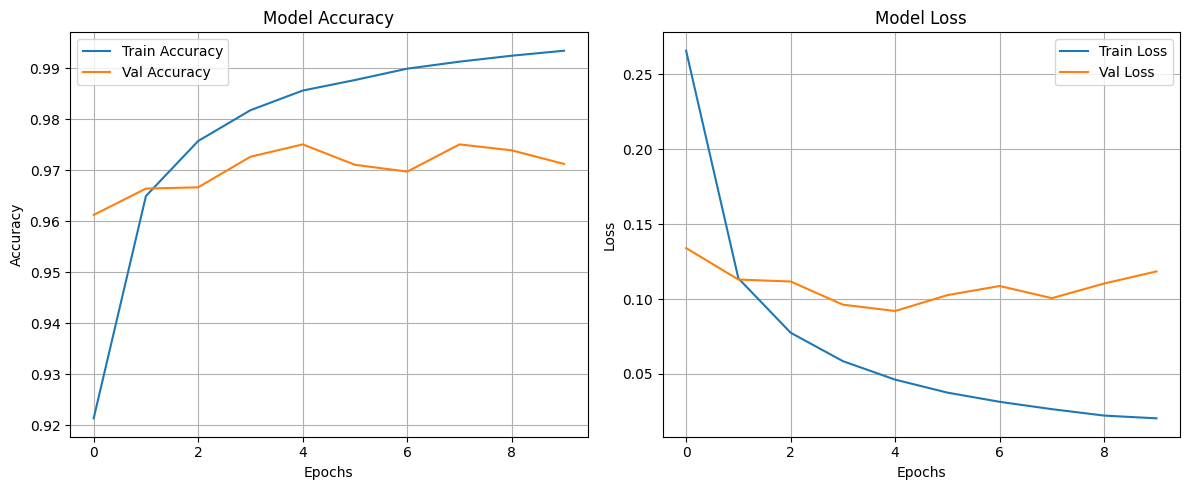

In [8]:
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()  # Display the plots

Step 8 : Making Predictions and Visualizing Results


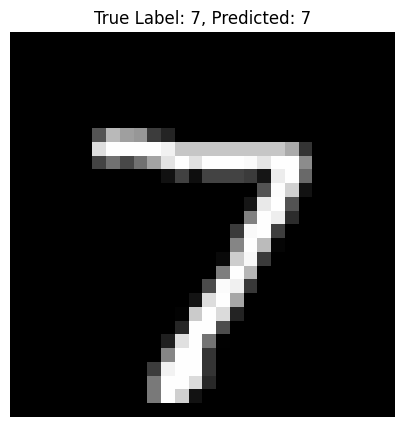

In [9]:
predictions = model.predict(test_images, verbose=0)

plt.figure(figsize=(5, 5))
plt.imshow(test_images[0], cmap='gray')
plt.title(f"True Label: {np.argmax(test_labels[0])}, Predicted: {np.argmax(predictions[0])}")
plt.axis('off')
plt.show()


# Tasks

The task section below is reorganized so the notebook maps cleanly to the PDF:
1. Baseline PyTorch implementation
2. Architecture experiments
3. Optimizer comparison
4. Epoch / overfitting-underfitting study
5. Early stopping and regularization experiments
6. Consolidated results table and comparison plots

## Task 01 — PyTorch baseline + reusable experiment utilities

In [10]:
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=split_generator
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

all_experiment_rows = []
all_histories = {}

def get_activation(name: str):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(f"Unsupported activation: {name}")

class ConfigurableMLP(nn.Module):
    def __init__(self, hidden_layers=(128, 64), activation="relu", dropout=0.0, l2_lambda=0.0):
        super().__init__()
        self.hidden_layers = tuple(hidden_layers)
        self.activation_name = activation
        self.dropout = dropout
        self.l2_lambda = l2_lambda

        layers = [nn.Flatten()]
        in_features = 28 * 28

        for hidden_dim in self.hidden_layers:
            layers.append(nn.Linear(in_features, hidden_dim))
            layers.append(get_activation(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_dim

        layers.append(nn.Linear(in_features, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def make_optimizer(name, params, lr=0.001, weight_decay=0.0):
    name = name.lower()
    if name == "adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "rmsprop":
        return optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Unsupported optimizer: {name}")

def calculate_accuracy(outputs, labels):
    preds = outputs.argmax(dim=1)
    return (preds == labels).float().mean().item()

def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size_local = labels.size(0)
            total_loss += loss.item() * batch_size_local
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size_local

    return total_loss / total_samples, total_correct / total_samples

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, early_stopping_patience=None):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_size_local = labels.size(0)
            total_loss += loss.item() * batch_size_local
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size_local

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        if early_stopping_patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"Early stopping triggered at epoch {epoch + 1}.")
                    break

    if early_stopping_patience is not None:
        model.load_state_dict(best_model_wts)

    train_time = time.time() - start_time
    return model, history, train_time

def test_model(model, test_loader, criterion):
    return evaluate_model(model, test_loader, criterion)

def interpret_fit(history, gap_threshold=0.03):
    train_acc = history["train_acc"][-1]
    val_acc = history["val_acc"][-1]
    train_loss = history["train_loss"][-1]
    val_loss = history["val_loss"][-1]
    acc_gap = train_acc - val_acc

    if train_acc < 0.92 and val_acc < 0.92:
        return "Likely underfitting: both train and validation accuracy are still relatively low."
    if acc_gap > gap_threshold and val_loss > min(history["val_loss"]):
        return "Possible overfitting: training accuracy is noticeably higher than validation accuracy."
    return "Reasonably well-fitted: train and validation curves are close and validation performance is stable."

def run_experiment(
    exp_no,
    section,
    exp_name,
    hidden_layers=(128, 64),
    activation="relu",
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=10,
    dropout=0.0,
    l2_lambda=0.0,
    early_stopping_patience=None,
    show_curves=True
):
    print(f"\n=== Experiment {exp_no}: {exp_name} ===")

    model = ConfigurableMLP(
        hidden_layers=hidden_layers,
        activation=activation,
        dropout=dropout,
        l2_lambda=l2_lambda
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(
        optimizer_name,
        model.parameters(),
        lr=learning_rate,
        weight_decay=l2_lambda
    )

    model, history, train_time = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=epochs,
        early_stopping_patience=early_stopping_patience
    )

    test_loss, test_acc = test_model(model, test_loader, criterion)
    fit_comment = interpret_fit(history)

    row = {
        "experiment_no": exp_no,
        "section": section,
        "name": exp_name,
        "architecture": str(tuple(hidden_layers)),
        "activation": activation,
        "optimizer": optimizer_name,
        "learning_rate": learning_rate,
        "epochs_requested": epochs,
        "epochs_run": len(history["train_loss"]),
        "dropout": dropout,
        "l2_lambda": l2_lambda,
        "early_stopping_patience": early_stopping_patience,
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1],
        "test_acc": test_acc,
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "test_loss": test_loss,
        "train_time_sec": train_time,
        "fit_comment": fit_comment,
    }

    all_experiment_rows.append(row)
    all_histories[exp_no] = history

    if show_curves:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(history["train_acc"], label="Train Accuracy")
        axes[0].plot(history["val_acc"], label="Val Accuracy")
        axes[0].set_title(f"Experiment {exp_no} Accuracy")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Accuracy")
        axes[0].grid(True)
        axes[0].legend()

        axes[1].plot(history["train_loss"], label="Train Loss")
        axes[1].plot(history["val_loss"], label="Val Loss")
        axes[1].set_title(f"Experiment {exp_no} Loss")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Loss")
        axes[1].grid(True)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
    print("Interpretation:", fit_comment)

    return model, history, row

def results_table(sort_by="test_acc", ascending=False):
    df = pd.DataFrame(all_experiment_rows)
    if df.empty:
        return df
    df = df.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    return df

def display_results_table(sort_by="test_acc", ascending=False):
    df = results_table(sort_by=sort_by, ascending=ascending).copy()
    if df.empty:
        print("No experiments logged yet.")
        return df

    display_cols = [
        "experiment_no", "section", "name", "architecture", "activation",
        "optimizer", "learning_rate", "epochs_requested", "epochs_run",
        "dropout", "l2_lambda", "early_stopping_patience",
        "final_train_acc", "final_val_acc", "test_acc",
        "final_train_loss", "final_val_loss", "test_loss", "fit_comment"
    ]
    for col in ["final_train_acc", "final_val_acc", "test_acc", "final_train_loss", "final_val_loss", "test_loss"]:
        df[col] = df[col].round(4)
    return df[display_cols]

def plot_histories(exp_nos=None, metric="loss"):
    if exp_nos is None:
        exp_nos = sorted(all_histories.keys())

    plt.figure(figsize=(10, 5))
    for exp_no in exp_nos:
        history = all_histories[exp_no]
        if metric == "loss":
            plt.plot(history["val_loss"], label=f"Exp {exp_no} val loss")
        elif metric == "accuracy":
            plt.plot(history["val_acc"], label=f"Exp {exp_no} val acc")
        else:
            raise ValueError("metric must be 'loss' or 'accuracy'")

    plt.title(f"Validation {metric.capitalize()} Curves")
    plt.xlabel("Epoch")
    plt.ylabel(metric.capitalize())
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def show_predictions(model, test_loader, num_images=9):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"True: {labels[i].item()} | Pred: {preds[i].item()}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


## Baseline model

Keep one clean baseline ANN before the task experiments so the report has a single reference point.


=== Experiment 1: PyTorch baseline (128, 64) + ReLU + Adam ===
Epoch [1/10] | Train Loss: 0.4298, Train Acc: 0.8739 | Val Loss: 0.2730, Val Acc: 0.9213
Epoch [2/10] | Train Loss: 0.2117, Train Acc: 0.9351 | Val Loss: 0.1792, Val Acc: 0.9461
Epoch [3/10] | Train Loss: 0.1496, Train Acc: 0.9546 | Val Loss: 0.1629, Val Acc: 0.9510
Epoch [4/10] | Train Loss: 0.1218, Train Acc: 0.9623 | Val Loss: 0.1330, Val Acc: 0.9587
Epoch [5/10] | Train Loss: 0.1009, Train Acc: 0.9678 | Val Loss: 0.1240, Val Acc: 0.9643
Epoch [6/10] | Train Loss: 0.0877, Train Acc: 0.9725 | Val Loss: 0.1186, Val Acc: 0.9642
Epoch [7/10] | Train Loss: 0.0788, Train Acc: 0.9746 | Val Loss: 0.1168, Val Acc: 0.9668
Epoch [8/10] | Train Loss: 0.0717, Train Acc: 0.9776 | Val Loss: 0.1160, Val Acc: 0.9663
Epoch [9/10] | Train Loss: 0.0683, Train Acc: 0.9781 | Val Loss: 0.1048, Val Acc: 0.9707
Epoch [10/10] | Train Loss: 0.0574, Train Acc: 0.9814 | Val Loss: 0.0981, Val Acc: 0.9724


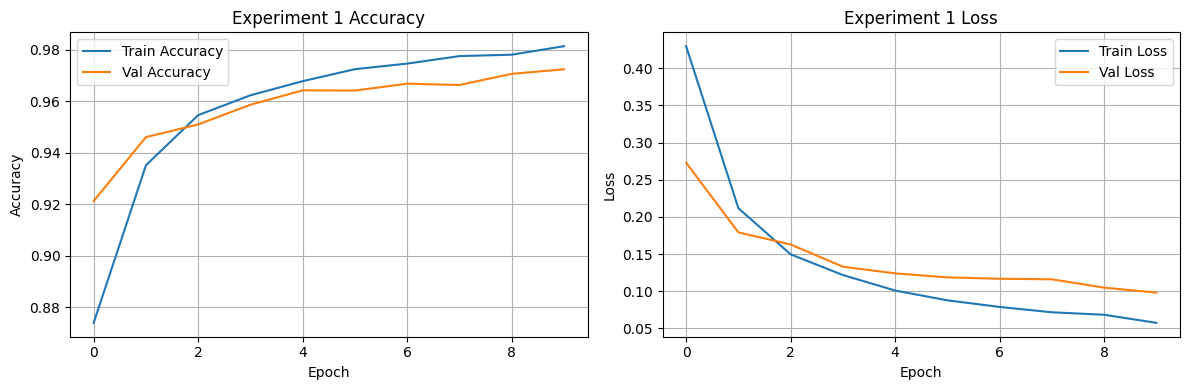

Test Loss: 0.0869 | Test Accuracy: 0.9737
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.


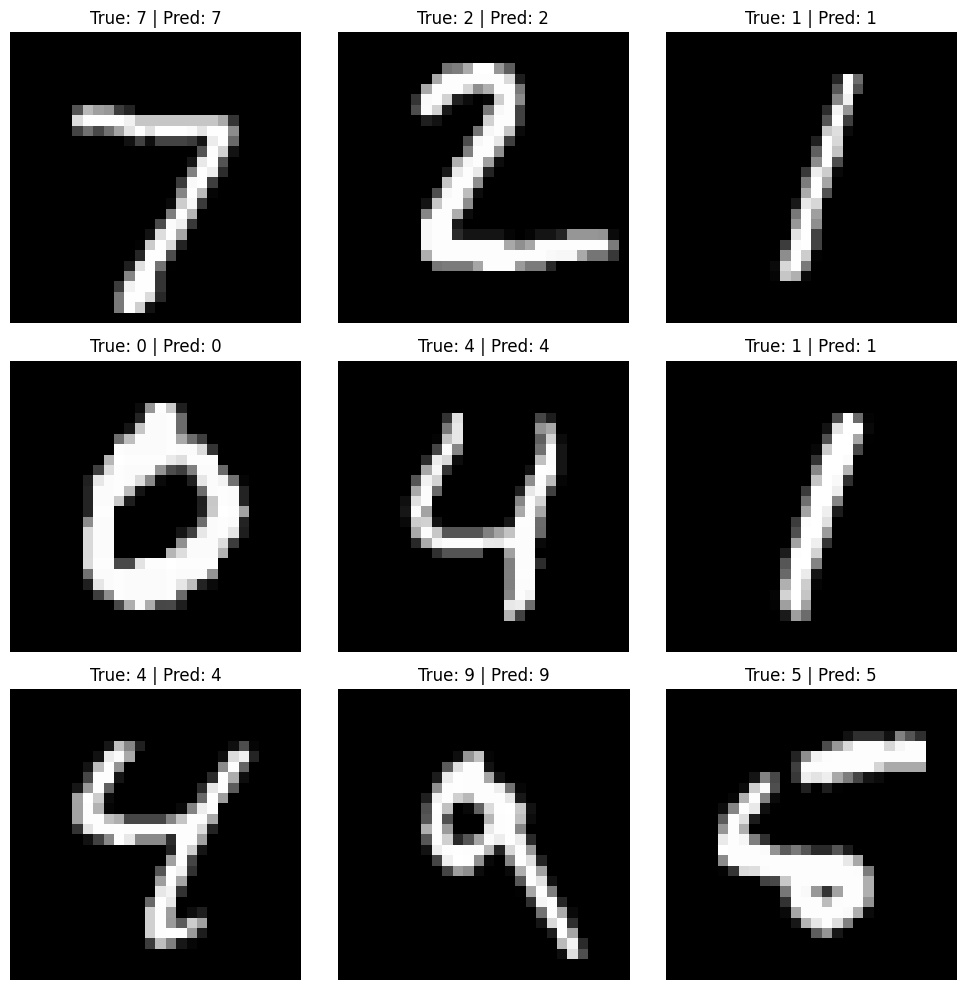

,experiment_no,section,name,architecture,activation,optimizer,learning_rate,epochs_requested,epochs_run,dropout,l2_lambda,early_stopping_patience,final_train_acc,final_val_acc,test_acc,final_train_loss,final_val_loss,test_loss,fit_comment
0,1,Baseline,"PyTorch baseline (128, 64) + ReLU + Adam","(128, 64)",relu,adam,0.001,10,10,0.0,0.0,None,0.9814,0.9724,0.9737,0.0574,0.0981,0.0869,Reasonably well-fitted: train and validation c...


In [11]:
baseline_model, baseline_history, baseline_row = run_experiment(
    exp_no=1,
    section="Baseline",
    exp_name="PyTorch baseline (128, 64) + ReLU + Adam",
    hidden_layers=(128, 64),
    activation="relu",
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=10,
    dropout=0.0,
    l2_lambda=0.0,
    early_stopping_patience=None,
    show_curves=True
)

show_predictions(baseline_model, test_loader)
display_results_table()

## Task 02 — Architecture experiments

Change the number of layers / neurons / activations while keeping the optimizer setup fixed for a fair comparison.


=== Experiment 2: Smaller network (64) ===
Epoch [1/10] | Train Loss: 0.4628, Train Acc: 0.8688 | Val Loss: 0.3286, Val Acc: 0.9021
Epoch [2/10] | Train Loss: 0.2740, Train Acc: 0.9204 | Val Loss: 0.2480, Val Acc: 0.9262
Epoch [3/10] | Train Loss: 0.2154, Train Acc: 0.9374 | Val Loss: 0.2103, Val Acc: 0.9404
Epoch [4/10] | Train Loss: 0.1772, Train Acc: 0.9480 | Val Loss: 0.1931, Val Acc: 0.9437
Epoch [5/10] | Train Loss: 0.1548, Train Acc: 0.9544 | Val Loss: 0.1691, Val Acc: 0.9507
Epoch [6/10] | Train Loss: 0.1331, Train Acc: 0.9610 | Val Loss: 0.1514, Val Acc: 0.9555
Epoch [7/10] | Train Loss: 0.1228, Train Acc: 0.9633 | Val Loss: 0.1513, Val Acc: 0.9568
Epoch [8/10] | Train Loss: 0.1140, Train Acc: 0.9655 | Val Loss: 0.1411, Val Acc: 0.9605
Epoch [9/10] | Train Loss: 0.1043, Train Acc: 0.9686 | Val Loss: 0.1549, Val Acc: 0.9536
Epoch [10/10] | Train Loss: 0.0981, Train Acc: 0.9700 | Val Loss: 0.1540, Val Acc: 0.9547


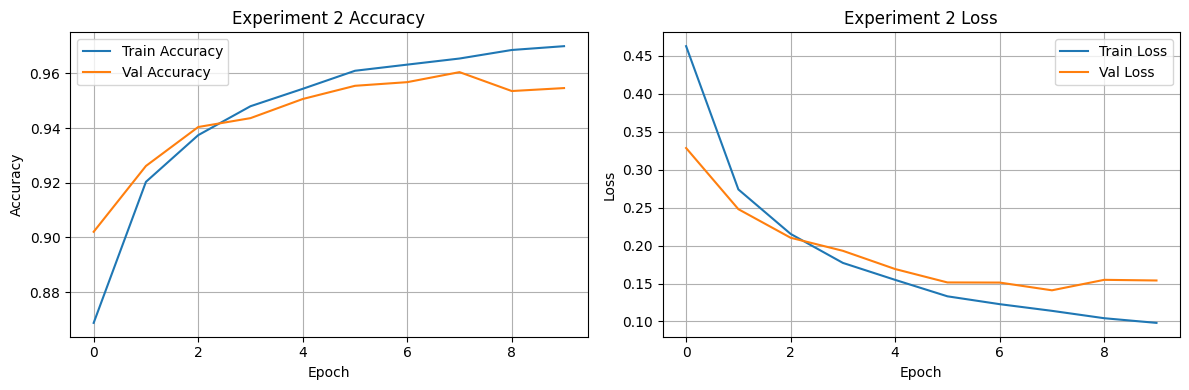

Test Loss: 0.1376 | Test Accuracy: 0.9602
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 3: Original size (128, 64) ===
Epoch [1/10] | Train Loss: 0.4237, Train Acc: 0.8748 | Val Loss: 0.2677, Val Acc: 0.9193
Epoch [2/10] | Train Loss: 0.2069, Train Acc: 0.9370 | Val Loss: 0.1861, Val Acc: 0.9411
Epoch [3/10] | Train Loss: 0.1491, Train Acc: 0.9541 | Val Loss: 0.1446, Val Acc: 0.9570
Epoch [4/10] | Train Loss: 0.1205, Train Acc: 0.9624 | Val Loss: 0.1496, Val Acc: 0.9554
Epoch [5/10] | Train Loss: 0.1013, Train Acc: 0.9686 | Val Loss: 0.1257, Val Acc: 0.9614
Epoch [6/10] | Train Loss: 0.0930, Train Acc: 0.9697 | Val Loss: 0.1195, Val Acc: 0.9632
Epoch [7/10] | Train Loss: 0.0776, Train Acc: 0.9758 | Val Loss: 0.1232, Val Acc: 0.9630
Epoch [8/10] | Train Loss: 0.0737, Train Acc: 0.9763 | Val Loss: 0.1213, Val Acc: 0.9643
Epoch [9/10] | Train Loss: 0.0629, Train Acc: 0.9800 | Val Loss: 0.1102, Val Acc: 0

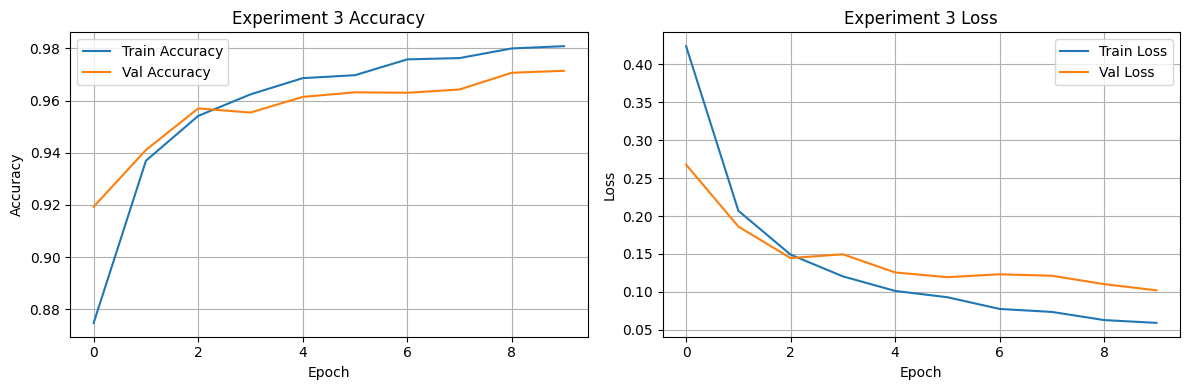

Test Loss: 0.0931 | Test Accuracy: 0.9736
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 4: Wider network (256, 128) ===
Epoch [1/10] | Train Loss: 0.3782, Train Acc: 0.8865 | Val Loss: 0.2490, Val Acc: 0.9261
Epoch [2/10] | Train Loss: 0.1712, Train Acc: 0.9480 | Val Loss: 0.1584, Val Acc: 0.9509
Epoch [3/10] | Train Loss: 0.1253, Train Acc: 0.9613 | Val Loss: 0.1259, Val Acc: 0.9615
Epoch [4/10] | Train Loss: 0.0962, Train Acc: 0.9703 | Val Loss: 0.1209, Val Acc: 0.9627
Epoch [5/10] | Train Loss: 0.0824, Train Acc: 0.9738 | Val Loss: 0.1234, Val Acc: 0.9641
Epoch [6/10] | Train Loss: 0.0715, Train Acc: 0.9761 | Val Loss: 0.0971, Val Acc: 0.9694
Epoch [7/10] | Train Loss: 0.0630, Train Acc: 0.9799 | Val Loss: 0.1025, Val Acc: 0.9677
Epoch [8/10] | Train Loss: 0.0550, Train Acc: 0.9820 | Val Loss: 0.1137, Val Acc: 0.9677
Epoch [9/10] | Train Loss: 0.0509, Train Acc: 0.9833 | Val Loss: 0.1014, Val Acc: 

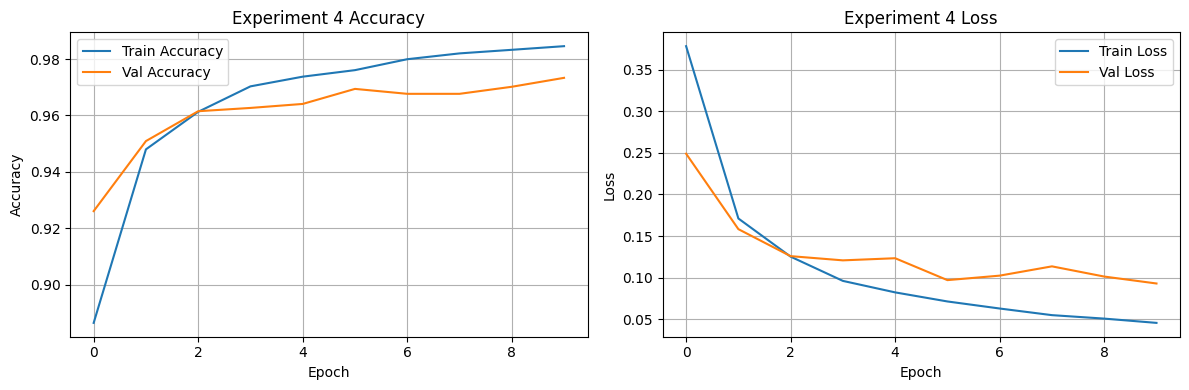

Test Loss: 0.0785 | Test Accuracy: 0.9780
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 5: Deeper network (256, 128, 64) ===
Epoch [1/10] | Train Loss: 0.4027, Train Acc: 0.8752 | Val Loss: 0.2117, Val Acc: 0.9342
Epoch [2/10] | Train Loss: 0.1776, Train Acc: 0.9459 | Val Loss: 0.1736, Val Acc: 0.9463
Epoch [3/10] | Train Loss: 0.1275, Train Acc: 0.9602 | Val Loss: 0.1264, Val Acc: 0.9623
Epoch [4/10] | Train Loss: 0.1015, Train Acc: 0.9684 | Val Loss: 0.1340, Val Acc: 0.9614
Epoch [5/10] | Train Loss: 0.0910, Train Acc: 0.9707 | Val Loss: 0.1492, Val Acc: 0.9563
Epoch [6/10] | Train Loss: 0.0762, Train Acc: 0.9757 | Val Loss: 0.1101, Val Acc: 0.9673
Epoch [7/10] | Train Loss: 0.0714, Train Acc: 0.9768 | Val Loss: 0.1205, Val Acc: 0.9649
Epoch [8/10] | Train Loss: 0.0604, Train Acc: 0.9809 | Val Loss: 0.1128, Val Acc: 0.9664
Epoch [9/10] | Train Loss: 0.0537, Train Acc: 0.9828 | Val Loss: 0.1093, Val 

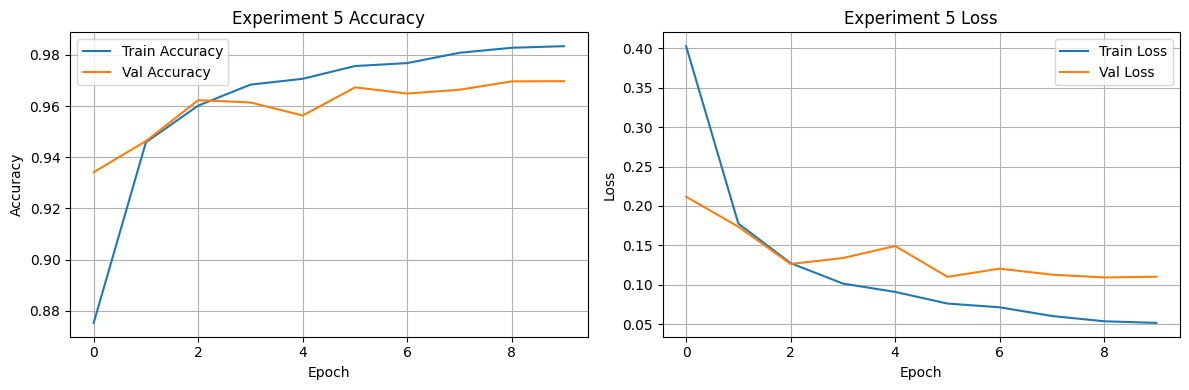

Test Loss: 0.0908 | Test Accuracy: 0.9720
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 6: Deeper network + tanh ===
Epoch [1/10] | Train Loss: 0.3666, Train Acc: 0.8945 | Val Loss: 0.2267, Val Acc: 0.9323
Epoch [2/10] | Train Loss: 0.1737, Train Acc: 0.9471 | Val Loss: 0.1694, Val Acc: 0.9490
Epoch [3/10] | Train Loss: 0.1400, Train Acc: 0.9579 | Val Loss: 0.1668, Val Acc: 0.9507
Epoch [4/10] | Train Loss: 0.1234, Train Acc: 0.9615 | Val Loss: 0.1812, Val Acc: 0.9422
Epoch [5/10] | Train Loss: 0.1146, Train Acc: 0.9641 | Val Loss: 0.1507, Val Acc: 0.9537
Epoch [6/10] | Train Loss: 0.1022, Train Acc: 0.9678 | Val Loss: 0.1231, Val Acc: 0.9642
Epoch [7/10] | Train Loss: 0.0964, Train Acc: 0.9704 | Val Loss: 0.1250, Val Acc: 0.9637
Epoch [8/10] | Train Loss: 0.0917, Train Acc: 0.9712 | Val Loss: 0.1429, Val Acc: 0.9580
Epoch [9/10] | Train Loss: 0.0897, Train Acc: 0.9724 | Val Loss: 0.1241, Val Acc: 0.9

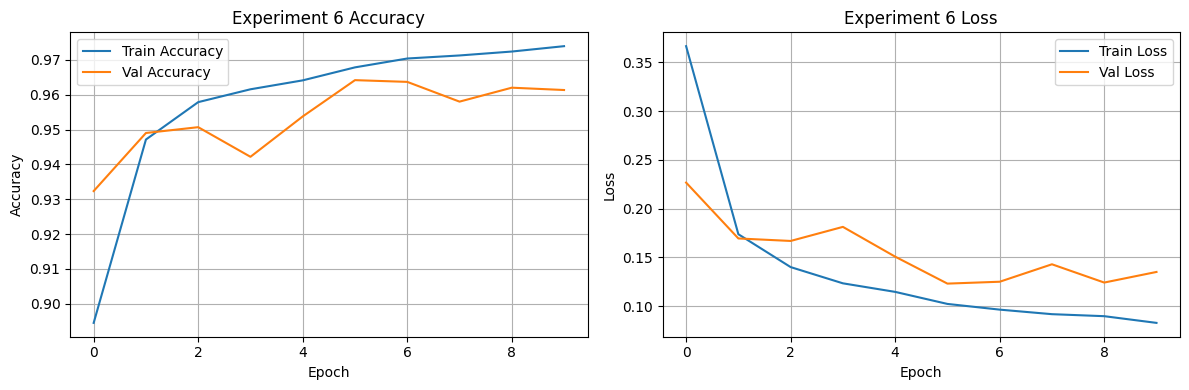

Test Loss: 0.1241 | Test Accuracy: 0.9620
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.


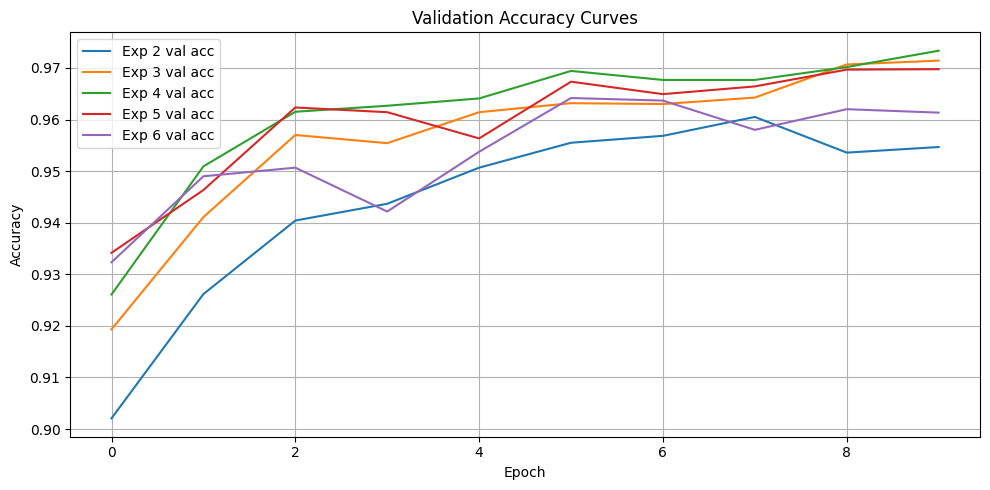

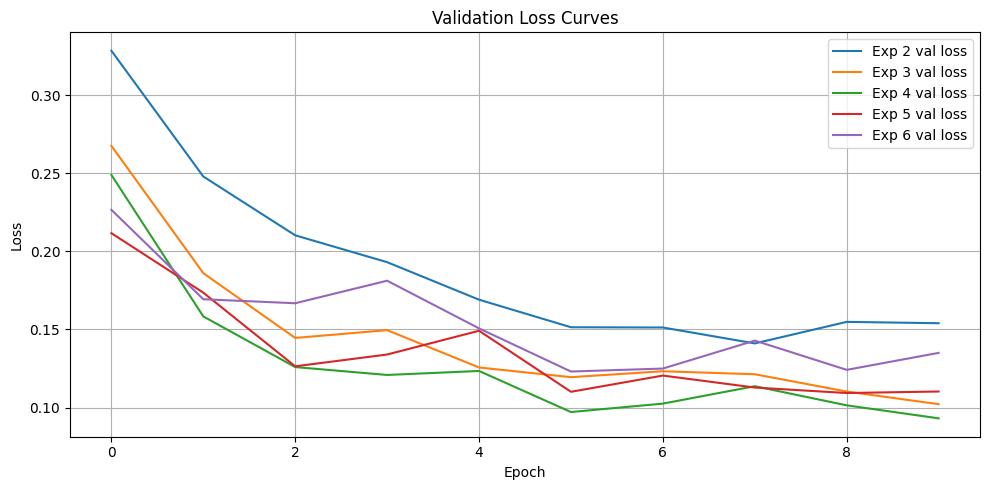

In [12]:
architecture_experiments = [
    dict(exp_no=2, section="Architecture", exp_name="Smaller network (64)", hidden_layers=(64,), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=10, dropout=0.0, l2_lambda=0.0),
    dict(exp_no=3, section="Architecture", exp_name="Original size (128, 64)", hidden_layers=(128, 64), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=10, dropout=0.0, l2_lambda=0.0),
    dict(exp_no=4, section="Architecture", exp_name="Wider network (256, 128)", hidden_layers=(256, 128), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=10, dropout=0.0, l2_lambda=0.0),
    dict(exp_no=5, section="Architecture", exp_name="Deeper network (256, 128, 64)", hidden_layers=(256, 128, 64), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=10, dropout=0.0, l2_lambda=0.0),
    dict(exp_no=6, section="Architecture", exp_name="Deeper network + tanh", hidden_layers=(256, 128, 64), activation="tanh", optimizer_name="adam", learning_rate=0.001, epochs=10, dropout=0.0, l2_lambda=0.0),
]

for cfg in architecture_experiments:
    run_experiment(**cfg, early_stopping_patience=None, show_curves=True)

display_results_table()
plot_histories(exp_nos=[2, 3, 4, 5, 6], metric="accuracy")
plot_histories(exp_nos=[2, 3, 4, 5, 6], metric="loss")

### Interpretation notes

Use a short note like this after the architecture plots:

- If both train and validation accuracy stay low, the network is likely underfitting.
- If train accuracy rises much higher than validation accuracy, the network is likely overfitting.
- If the curves stay close and validation accuracy is high, the model is reasonably well-fitted.

## Task 03 — Optimizer comparison

Keep architecture fixed at the baseline and only change the optimizer.


=== Experiment 7: SGD baseline architecture ===
Epoch [1/10] | Train Loss: 0.4821, Train Acc: 0.8519 | Val Loss: 0.2493, Val Acc: 0.9253
Epoch [2/10] | Train Loss: 0.1991, Train Acc: 0.9391 | Val Loss: 0.1850, Val Acc: 0.9427
Epoch [3/10] | Train Loss: 0.1405, Train Acc: 0.9573 | Val Loss: 0.1657, Val Acc: 0.9483
Epoch [4/10] | Train Loss: 0.1113, Train Acc: 0.9664 | Val Loss: 0.1246, Val Acc: 0.9628
Epoch [5/10] | Train Loss: 0.0935, Train Acc: 0.9712 | Val Loss: 0.1248, Val Acc: 0.9619
Epoch [6/10] | Train Loss: 0.0816, Train Acc: 0.9744 | Val Loss: 0.1215, Val Acc: 0.9633
Epoch [7/10] | Train Loss: 0.0686, Train Acc: 0.9782 | Val Loss: 0.1014, Val Acc: 0.9699
Epoch [8/10] | Train Loss: 0.0612, Train Acc: 0.9810 | Val Loss: 0.0967, Val Acc: 0.9720
Epoch [9/10] | Train Loss: 0.0543, Train Acc: 0.9829 | Val Loss: 0.1032, Val Acc: 0.9697
Epoch [10/10] | Train Loss: 0.0496, Train Acc: 0.9841 | Val Loss: 0.1015, Val Acc: 0.9697


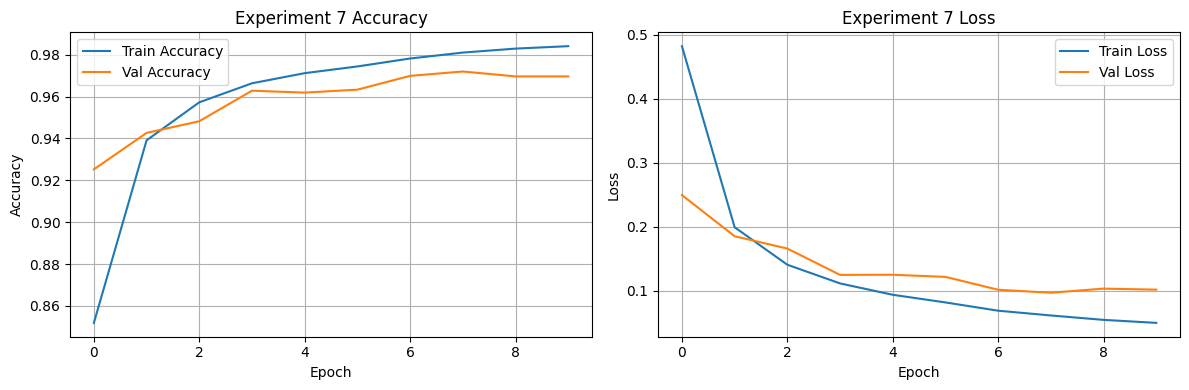

Test Loss: 0.0895 | Test Accuracy: 0.9744
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 8: RMSprop baseline architecture ===
Epoch [1/10] | Train Loss: 0.4266, Train Acc: 0.8698 | Val Loss: 0.2526, Val Acc: 0.9233
Epoch [2/10] | Train Loss: 0.2078, Train Acc: 0.9369 | Val Loss: 0.2092, Val Acc: 0.9362
Epoch [3/10] | Train Loss: 0.1541, Train Acc: 0.9525 | Val Loss: 0.1822, Val Acc: 0.9448
Epoch [4/10] | Train Loss: 0.1251, Train Acc: 0.9615 | Val Loss: 0.1335, Val Acc: 0.9603
Epoch [5/10] | Train Loss: 0.1055, Train Acc: 0.9672 | Val Loss: 0.1188, Val Acc: 0.9625
Epoch [6/10] | Train Loss: 0.0931, Train Acc: 0.9705 | Val Loss: 0.1132, Val Acc: 0.9665
Epoch [7/10] | Train Loss: 0.0838, Train Acc: 0.9726 | Val Loss: 0.1164, Val Acc: 0.9653
Epoch [8/10] | Train Loss: 0.0757, Train Acc: 0.9760 | Val Loss: 0.1262, Val Acc: 0.9653
Epoch [9/10] | Train Loss: 0.0673, Train Acc: 0.9779 | Val Loss: 0.1281, Val 

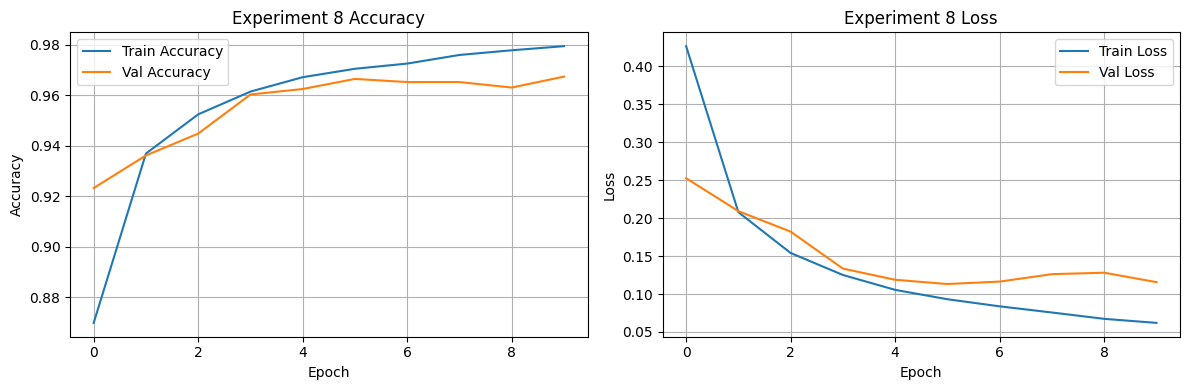

Test Loss: 0.1037 | Test Accuracy: 0.9699
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 9: Adam baseline architecture ===
Epoch [1/10] | Train Loss: 0.4302, Train Acc: 0.8713 | Val Loss: 0.3108, Val Acc: 0.9032
Epoch [2/10] | Train Loss: 0.2164, Train Acc: 0.9344 | Val Loss: 0.1888, Val Acc: 0.9423
Epoch [3/10] | Train Loss: 0.1562, Train Acc: 0.9530 | Val Loss: 0.1552, Val Acc: 0.9533
Epoch [4/10] | Train Loss: 0.1247, Train Acc: 0.9622 | Val Loss: 0.1358, Val Acc: 0.9577
Epoch [5/10] | Train Loss: 0.1061, Train Acc: 0.9668 | Val Loss: 0.1276, Val Acc: 0.9601
Epoch [6/10] | Train Loss: 0.0867, Train Acc: 0.9722 | Val Loss: 0.1069, Val Acc: 0.9683
Epoch [7/10] | Train Loss: 0.0803, Train Acc: 0.9746 | Val Loss: 0.1112, Val Acc: 0.9669
Epoch [8/10] | Train Loss: 0.0692, Train Acc: 0.9781 | Val Loss: 0.1037, Val Acc: 0.9692
Epoch [9/10] | Train Loss: 0.0652, Train Acc: 0.9790 | Val Loss: 0.1082, Val Acc

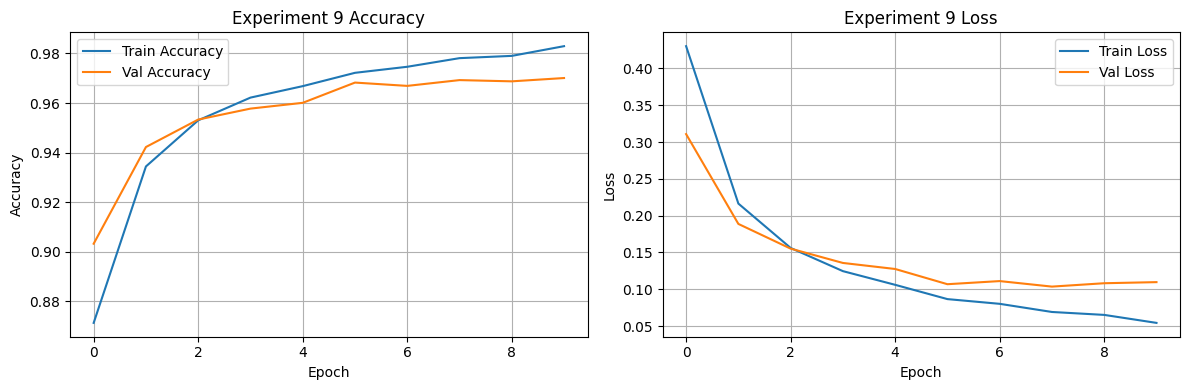

Test Loss: 0.1012 | Test Accuracy: 0.9718
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.


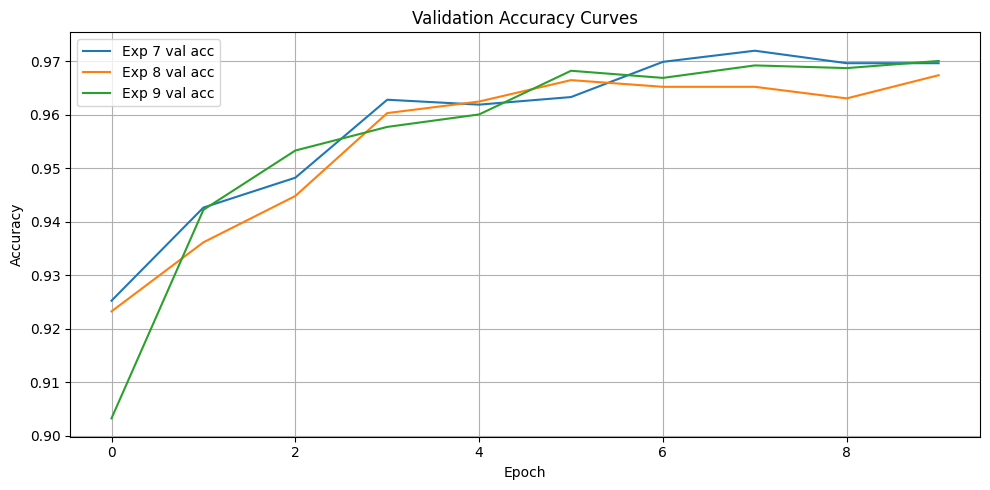

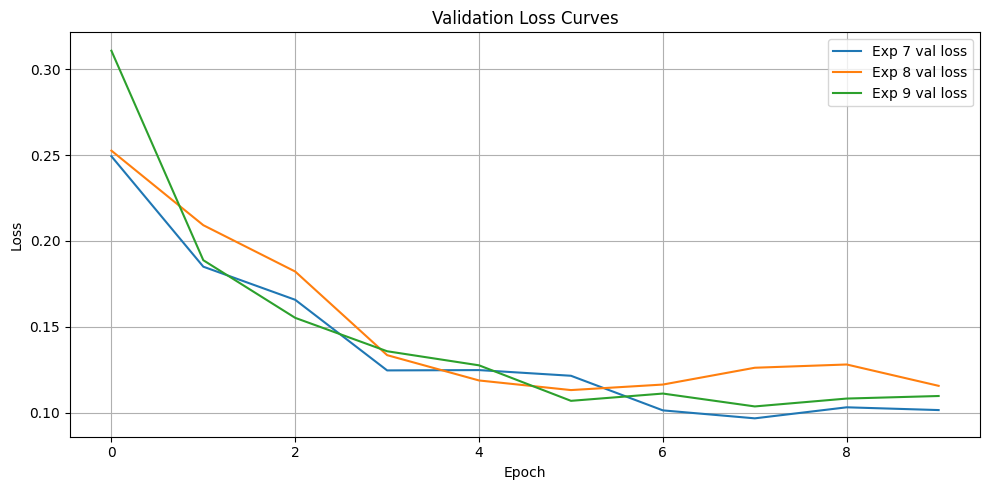

In [13]:
optimizer_experiments = [
    dict(exp_no=7, section="Optimizer", exp_name="SGD baseline architecture", hidden_layers=(128, 64), activation="relu", optimizer_name="sgd", learning_rate=0.01, epochs=10, dropout=0.0, l2_lambda=0.0),
    dict(exp_no=8, section="Optimizer", exp_name="RMSprop baseline architecture", hidden_layers=(128, 64), activation="relu", optimizer_name="rmsprop", learning_rate=0.001, epochs=10, dropout=0.0, l2_lambda=0.0),
    dict(exp_no=9, section="Optimizer", exp_name="Adam baseline architecture", hidden_layers=(128, 64), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=10, dropout=0.0, l2_lambda=0.0),
]

for cfg in optimizer_experiments:
    run_experiment(**cfg, early_stopping_patience=None, show_curves=True)

display_results_table()
plot_histories(exp_nos=[7, 8, 9], metric="accuracy")
plot_histories(exp_nos=[7, 8, 9], metric="loss")

## Task 04 — Effect of epochs, Early Stopping, and regularization

This section studies overfitting / underfitting directly.


=== Experiment 10: Too few epochs (3) ===
Epoch [1/3] | Train Loss: 0.4345, Train Acc: 0.8718 | Val Loss: 0.2728, Val Acc: 0.9184
Epoch [2/3] | Train Loss: 0.2098, Train Acc: 0.9380 | Val Loss: 0.1944, Val Acc: 0.9399
Epoch [3/3] | Train Loss: 0.1517, Train Acc: 0.9538 | Val Loss: 0.1462, Val Acc: 0.9566


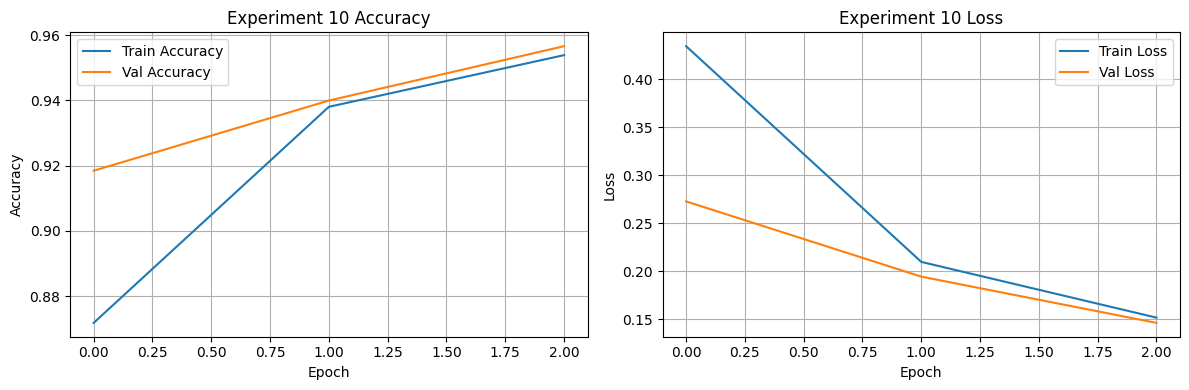

Test Loss: 0.1321 | Test Accuracy: 0.9601
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 11: Baseline epochs (10) ===
Epoch [1/10] | Train Loss: 0.4370, Train Acc: 0.8709 | Val Loss: 0.2940, Val Acc: 0.9139
Epoch [2/10] | Train Loss: 0.2174, Train Acc: 0.9347 | Val Loss: 0.2137, Val Acc: 0.9346
Epoch [3/10] | Train Loss: 0.1555, Train Acc: 0.9529 | Val Loss: 0.1486, Val Acc: 0.9538
Epoch [4/10] | Train Loss: 0.1227, Train Acc: 0.9627 | Val Loss: 0.1450, Val Acc: 0.9569
Epoch [5/10] | Train Loss: 0.1012, Train Acc: 0.9693 | Val Loss: 0.1269, Val Acc: 0.9614
Epoch [6/10] | Train Loss: 0.0897, Train Acc: 0.9714 | Val Loss: 0.1300, Val Acc: 0.9620
Epoch [7/10] | Train Loss: 0.0809, Train Acc: 0.9742 | Val Loss: 0.1142, Val Acc: 0.9677
Epoch [8/10] | Train Loss: 0.0740, Train Acc: 0.9764 | Val Loss: 0.1285, Val Acc: 0.9615
Epoch [9/10] | Train Loss: 0.0645, Train Acc: 0.9787 | Val Loss: 0.1132, Val Acc: 0.9

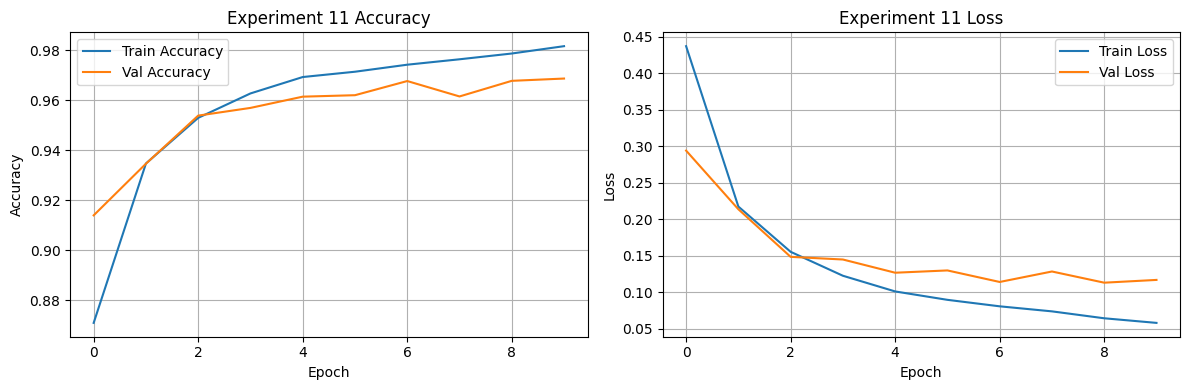

Test Loss: 0.0996 | Test Accuracy: 0.9697
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 12: More epochs (20) ===
Epoch [1/20] | Train Loss: 0.4353, Train Acc: 0.8715 | Val Loss: 0.2701, Val Acc: 0.9213
Epoch [2/20] | Train Loss: 0.2132, Train Acc: 0.9359 | Val Loss: 0.1846, Val Acc: 0.9455
Epoch [3/20] | Train Loss: 0.1537, Train Acc: 0.9533 | Val Loss: 0.1720, Val Acc: 0.9467
Epoch [4/20] | Train Loss: 0.1245, Train Acc: 0.9615 | Val Loss: 0.1438, Val Acc: 0.9570
Epoch [5/20] | Train Loss: 0.1037, Train Acc: 0.9684 | Val Loss: 0.1344, Val Acc: 0.9603
Epoch [6/20] | Train Loss: 0.0913, Train Acc: 0.9717 | Val Loss: 0.1324, Val Acc: 0.9601
Epoch [7/20] | Train Loss: 0.0778, Train Acc: 0.9752 | Val Loss: 0.1348, Val Acc: 0.9576
Epoch [8/20] | Train Loss: 0.0718, Train Acc: 0.9769 | Val Loss: 0.1070, Val Acc: 0.9698
Epoch [9/20] | Train Loss: 0.0626, Train Acc: 0.9798 | Val Loss: 0.1249, Val Acc: 0.9645


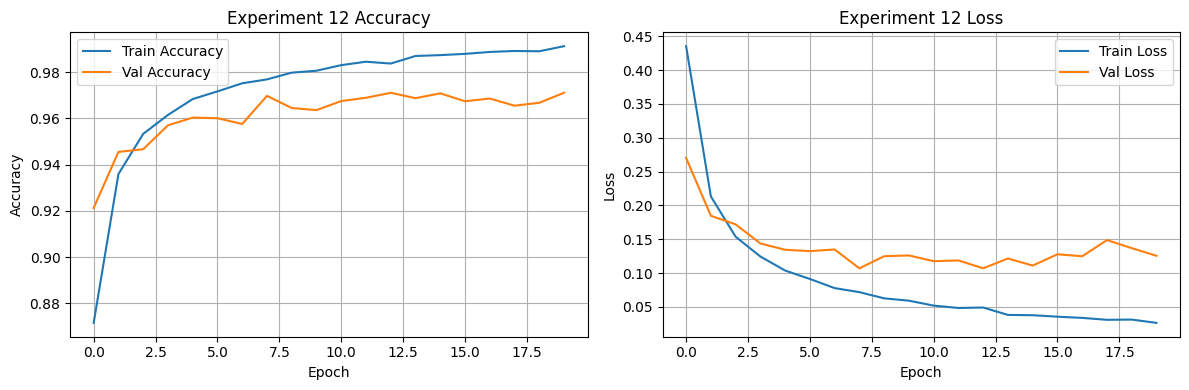

Test Loss: 0.1013 | Test Accuracy: 0.9754
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 13: EarlyStopping only ===
Epoch [1/20] | Train Loss: 0.4337, Train Acc: 0.8715 | Val Loss: 0.2981, Val Acc: 0.9101
Epoch [2/20] | Train Loss: 0.2156, Train Acc: 0.9360 | Val Loss: 0.1975, Val Acc: 0.9384
Epoch [3/20] | Train Loss: 0.1524, Train Acc: 0.9544 | Val Loss: 0.1657, Val Acc: 0.9507
Epoch [4/20] | Train Loss: 0.1226, Train Acc: 0.9627 | Val Loss: 0.1497, Val Acc: 0.9547
Epoch [5/20] | Train Loss: 0.1032, Train Acc: 0.9679 | Val Loss: 0.1505, Val Acc: 0.9533
Epoch [6/20] | Train Loss: 0.0902, Train Acc: 0.9716 | Val Loss: 0.1277, Val Acc: 0.9628
Epoch [7/20] | Train Loss: 0.0759, Train Acc: 0.9766 | Val Loss: 0.1186, Val Acc: 0.9638
Epoch [8/20] | Train Loss: 0.0720, Train Acc: 0.9769 | Val Loss: 0.1118, Val Acc: 0.9675
Epoch [9/20] | Train Loss: 0.0623, Train Acc: 0.9802 | Val Loss: 0.1091, Val Acc: 0.968

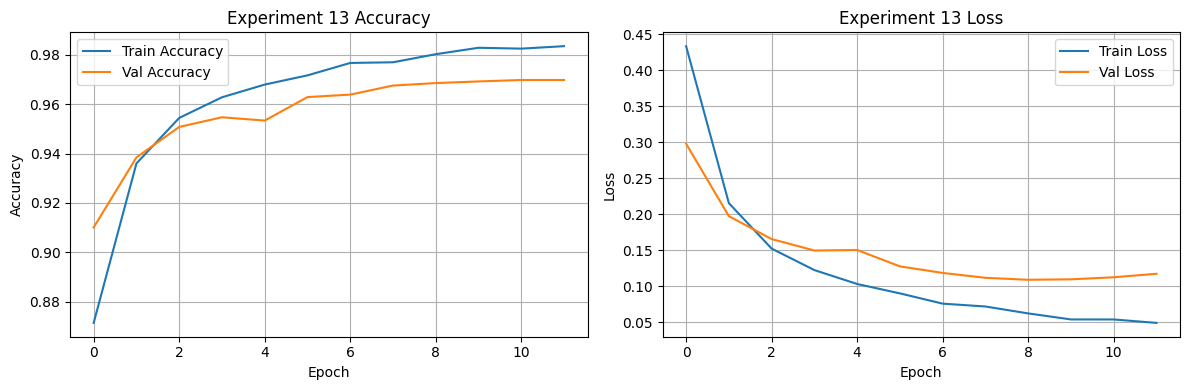

Test Loss: 0.0975 | Test Accuracy: 0.9710
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 14: Dropout 0.3 ===
Epoch [1/20] | Train Loss: 0.5987, Train Acc: 0.8118 | Val Loss: 0.2755, Val Acc: 0.9148
Epoch [2/20] | Train Loss: 0.3373, Train Acc: 0.9000 | Val Loss: 0.2213, Val Acc: 0.9343
Epoch [3/20] | Train Loss: 0.2801, Train Acc: 0.9155 | Val Loss: 0.2036, Val Acc: 0.9403
Epoch [4/20] | Train Loss: 0.2485, Train Acc: 0.9257 | Val Loss: 0.1691, Val Acc: 0.9509
Epoch [5/20] | Train Loss: 0.2344, Train Acc: 0.9307 | Val Loss: 0.1664, Val Acc: 0.9512
Epoch [6/20] | Train Loss: 0.2222, Train Acc: 0.9333 | Val Loss: 0.1610, Val Acc: 0.9527
Epoch [7/20] | Train Loss: 0.2163, Train Acc: 0.9347 | Val Loss: 0.1563, Val Acc: 0.9543
Epoch [8/20] | Train Loss: 0.2027, Train Acc: 0.9402 | Val Loss: 0.1534, Val Acc: 0.9563
Epoch [9/20] | Train Loss: 0.1949, Train Acc: 0.9412 | Val Loss: 0.1435, Val Acc: 0.9585
Epoch

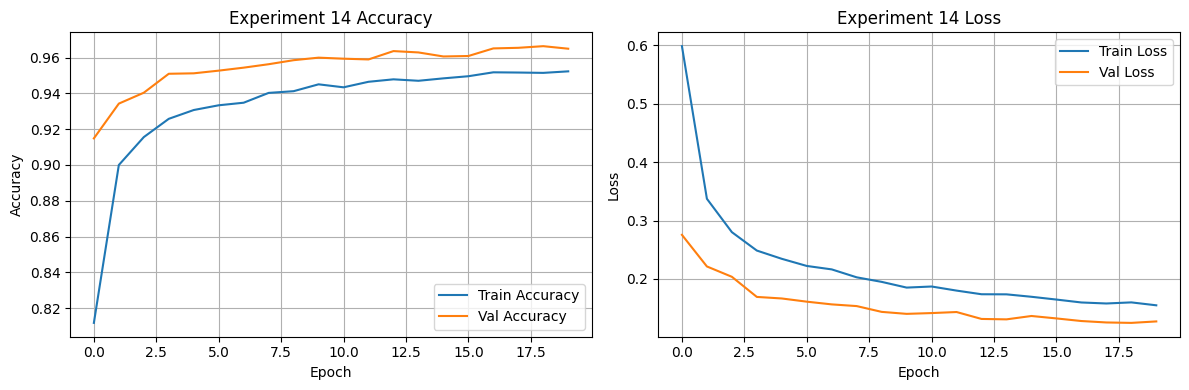

Test Loss: 0.1123 | Test Accuracy: 0.9677
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.

=== Experiment 15: L2 regularization ===
Epoch [1/20] | Train Loss: 0.4272, Train Acc: 0.8741 | Val Loss: 0.2563, Val Acc: 0.9256
Epoch [2/20] | Train Loss: 0.2028, Train Acc: 0.9390 | Val Loss: 0.1800, Val Acc: 0.9467
Epoch [3/20] | Train Loss: 0.1505, Train Acc: 0.9533 | Val Loss: 0.1509, Val Acc: 0.9555
Epoch [4/20] | Train Loss: 0.1240, Train Acc: 0.9618 | Val Loss: 0.1375, Val Acc: 0.9601
Epoch [5/20] | Train Loss: 0.1055, Train Acc: 0.9677 | Val Loss: 0.1446, Val Acc: 0.9562
Epoch [6/20] | Train Loss: 0.0923, Train Acc: 0.9705 | Val Loss: 0.1315, Val Acc: 0.9601
Epoch [7/20] | Train Loss: 0.0799, Train Acc: 0.9750 | Val Loss: 0.1123, Val Acc: 0.9675
Epoch [8/20] | Train Loss: 0.0731, Train Acc: 0.9772 | Val Loss: 0.1127, Val Acc: 0.9659
Epoch [9/20] | Train Loss: 0.0667, Train Acc: 0.9787 | Val Loss: 0.1154, Val Acc: 0.9657

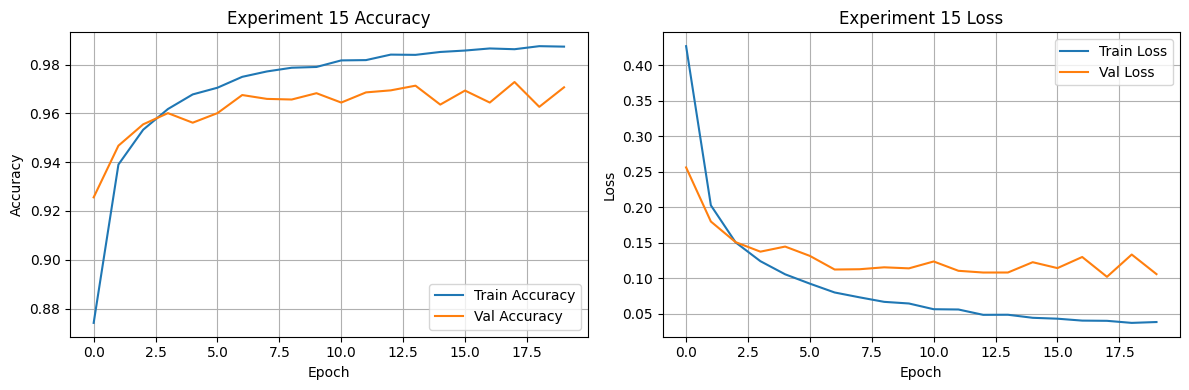

Test Loss: 0.0985 | Test Accuracy: 0.9732
Interpretation: Reasonably well-fitted: train and validation curves are close and validation performance is stable.


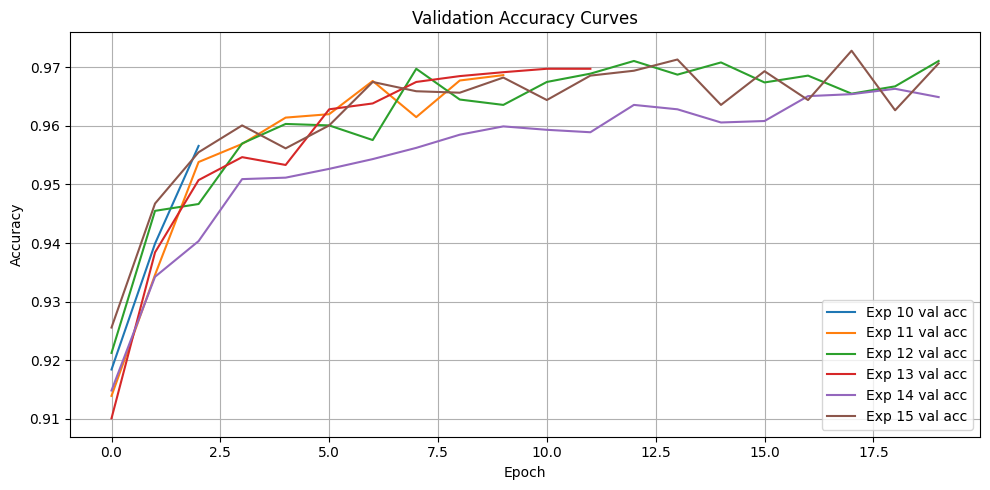

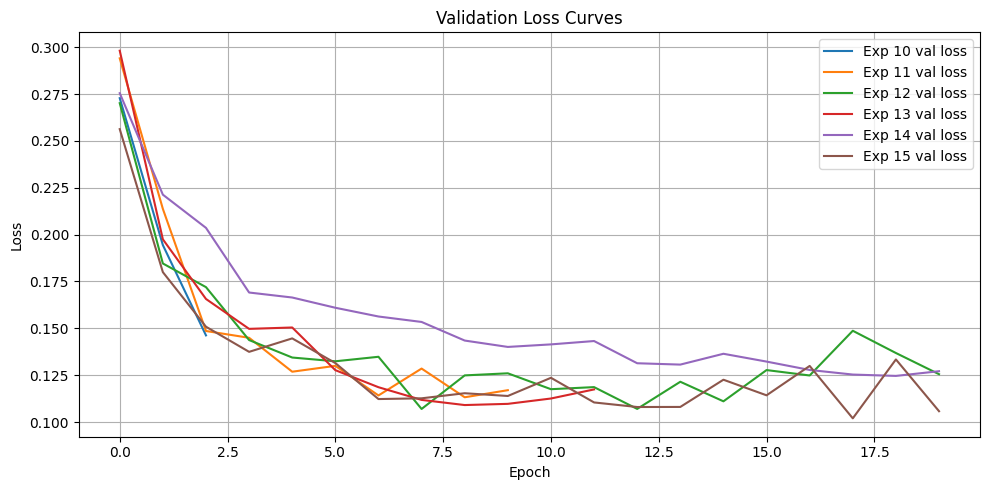

In [14]:
epoch_experiments = [
    dict(exp_no=10, section="Epochs", exp_name="Too few epochs (3)", hidden_layers=(128, 64), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=3, dropout=0.0, l2_lambda=0.0),
    dict(exp_no=11, section="Epochs", exp_name="Baseline epochs (10)", hidden_layers=(128, 64), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=10, dropout=0.0, l2_lambda=0.0),
    dict(exp_no=12, section="Epochs", exp_name="More epochs (20)", hidden_layers=(128, 64), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=20, dropout=0.0, l2_lambda=0.0),
]

for cfg in epoch_experiments:
    run_experiment(**cfg, early_stopping_patience=None, show_curves=True)

regularization_experiments = [
    dict(exp_no=13, section="Regularization", exp_name="EarlyStopping only", hidden_layers=(128, 64), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=20, dropout=0.0, l2_lambda=0.0, early_stopping_patience=3),
    dict(exp_no=14, section="Regularization", exp_name="Dropout 0.3", hidden_layers=(128, 64), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=20, dropout=0.3, l2_lambda=0.0, early_stopping_patience=None),
    dict(exp_no=15, section="Regularization", exp_name="L2 regularization", hidden_layers=(128, 64), activation="relu", optimizer_name="adam", learning_rate=0.001, epochs=20, dropout=0.0, l2_lambda=1e-4, early_stopping_patience=None),
]

for cfg in regularization_experiments:
    run_experiment(**cfg, show_curves=True)

display_results_table()
plot_histories(exp_nos=[10, 11, 12, 13, 14, 15], metric="accuracy")
plot_histories(exp_nos=[10, 11, 12, 13, 14, 15], metric="loss")

### Interpretation notes

You can write conclusions like:

- **Experiment 10** likely underfits because it does not train for enough epochs.
- **Experiment 12** may start to overfit if training accuracy keeps improving while validation stops improving.
- **Experiment 13** uses Early Stopping to stop training once validation loss no longer improves.
- **Experiment 14** uses Dropout to reduce co-adaptation and help generalization.
- **Experiment 15** uses L2 regularization to penalize overly large weights.

## Consolidated results table

This table compiles all experiments for the final report.

In [15]:
results_df = display_results_table(sort_by="test_acc", ascending=False)
results_df

,experiment_no,section,name,architecture,activation,optimizer,learning_rate,epochs_requested,epochs_run,dropout,l2_lambda,early_stopping_patience,final_train_acc,final_val_acc,test_acc,final_train_loss,final_val_loss,test_loss,fit_comment
0,4,Architecture,"Wider network (256, 128)","(256, 128)",relu,adam,0.001,10,10,0.0,0.0000,NaN,0.9846,0.9733,0.9780,0.0457,0.0931,0.0785,Reasonably well-fitted: train and validation c...
1,12,Epochs,More epochs (20),"(128, 64)",relu,adam,0.001,20,20,0.0,0.0000,NaN,0.9912,0.9711,0.9754,0.0264,0.1255,0.1013,Reasonably well-fitted: train and validation c...
2,7,Optimizer,SGD baseline architecture,"(128, 64)",relu,sgd,0.010,10,10,0.0,0.0000,NaN,0.9841,0.9697,0.9744,0.0496,0.1015,0.0895,Reasonably well-fitted: train and validation c...
3,1,Baseline,"PyTorch baseline (128, 64) + ReLU + Adam","(128, 64)",relu,adam,0.001,10,10,0.0,0.0000,NaN,0.9814,0.9724,0.9737,0.0574,0.0981,0.0869,Reasonably well-fitted: train and validation c...
4,3,Architecture,"Original size (128, 64)","(128, 64)",relu,adam,0.001,10,10,0.0,0.0000,NaN,0.9809,0.9714,0.9736,0.0592,0.1021,0.0931,Reasonably well-fitted: train and validation c...
5,15,Regularization,L2 regularization,"(128, 64)",relu,adam,0.001,20,20,0.0,0.0001,NaN,0.9873,0.9707,0.9732,0.0382,0.1058,0.0985,Reasonably well-fitted: train and validation c...
6,5,Architecture,"Deeper network (256, 128, 64)","(256, 128, 64)",relu,adam,0.001,10,10,0.0,0.0000,NaN,0.9834,0.9698,0.9720,0.0517,0.1103,0.0908,Reasonably well-fitted: train and validation c...
7,9,Optimizer,Adam baseline architecture,"(128, 64)",relu,adam,0.001,10,10,0.0,0.0000,NaN,0.9829,0.9701,0.9718,0.0544,0.1097,0.1012,Reasonably well-fitted: train and validation c...
8,13,Regularization,EarlyStopping only,"(128, 64)",relu,adam,0.001,20,12,0.0,0.0000,3.0,0.9834,0.9698,0.9710,0.0492,0.1174,0.0975,Reasonably well-fitted: train and validation c...
9,8,Optimizer,RMSprop baseline architecture,"(128, 64)",relu,rmsprop,0.001,10,10,0.0,0.0000,NaN,0.9795,0.9674,0.9699,0.0620,0.1156,0.1037,Reasonably well-fitted: train and validation c...
